### Exercise #1 Geomechanics and Structural Geology - 18 February 2026 (Part of Giovanni Bertotti)

- Pablo Oliver - 6483186
- Nanda Najih Habibil Afif - 6424732
- Lennard Stoeck - 6566545

### *Part 1: Stress Matrix and Mohr Diagram*

### *Task 1*
Provide a matrix and a Mohr diagram representation of the following states of stress:

- Hydrostatic compression at a water depth of 3 km
- Uniaxial tension ($\sigma_3$ = -5 MPa)
- Triaxial compression ($\sigma_3$ = 5 MPa; $\sigma_2$ = 8 MPa; $\sigma_1$ = 10 MPa)
- Tension and compression ($\sigma_3$ = -3 MPa; $\sigma_2$ = 0 MPa; $\sigma_1$ = 10 MPa)

### *Solution:*

For this task, the assumptions being used are:

- Compression is positive and tension is negative.
- Principal stress order is $\sigma_1 \geq \sigma_2 \geq \sigma_3$.
- For hydrostatic water load at depth $z = 3$ km:

$$p = \rho_w g z = 1000 \times 9.81 \times 3000 = 29.43\ \text{MPa}$$

- Stress tensor in principal coordinates is:

$$[\sigma] =
\begin{bmatrix}
\sigma_1 & 0 & 0 \\
0 & \sigma_2 & 0 \\
0 & 0 & \sigma_3
\end{bmatrix}$$

- Because each stress state is given with three principal stresses $(\sigma_1, \sigma_2, \sigma_3)$, so it is a 3D state of stress. Mohr circles in 3D are built from the pairs $(\sigma_1, \sigma_2)$, $(\sigma_2, \sigma_3)$, and $(\sigma_1, \sigma_3)$.

Direct formulas used:

- Circle $(\sigma_1, \sigma_2)$:

$$C_{12} = \frac{\sigma_1 + \sigma_2}{2}, \quad R_{12} = \frac{|\sigma_1 - \sigma_2|}{2}$$

- Circle $(\sigma_2, \sigma_3)$:

$$C_{23} = \frac{\sigma_2 + \sigma_3}{2}, \quad R_{23} = \frac{|\sigma_2 - \sigma_3|}{2}$$

- Circle $(\sigma_1, \sigma_3)$:

$$C_{13} = \frac{\sigma_1 + \sigma_3}{2}, \quad R_{13} = \frac{|\sigma_1 - \sigma_3|}{2}$$

$C$ is the center of a Mohr circle, $R$ is the radius of a Mohr circle (equal to the maximum shear stress for that pair).


In [53]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

def stress_tensor(sig1, sig2, sig3):
    return np.array([
        [sig1, 0.0, 0.0],
        [0.0, sig2, 0.0],
        [0.0, 0.0, sig3],
    ])

def mohr_params(sig1, sig2, sig3):
    pairs = [
        ("(sigma_1, sigma_3)", sig1, sig3),
        ("(sigma_1, sigma_2)", sig1, sig2),
        ("(sigma_2, sigma_3)", sig2, sig3),
    ]
    out = []
    for label, a, b in pairs:
        c = 0.5 * (a + b)
        r = 0.5 * abs(a - b)
        out.append((label, c, r))
    return out

def print_case_results(case_name, s1, s2, s3):
    print(case_name)
    print(f"sigma_1={s1:.2f} MPa, sigma_2={s2:.2f} MPa, sigma_3={s3:.2f} MPa")
    print("Stress matrix [MPa]:")
    print(stress_tensor(s1, s2, s3))
    print("Mohr circles (C, R) [MPa]:")
    for label, c, r in mohr_params(s1, s2, s3):
        print(f"  {label}: C={c:.2f}, R={r:.2f}")

# Case definitions
rho_w = 1000.0
g = 9.81
z = 3000.0
p_hydro = rho_w * g * z / 1e6  # MPa

cases = {
    "A) Hydrostatic compression (3 km water depth)": (p_hydro, p_hydro, p_hydro),
    "B) Uniaxial tension": (0.0, 0.0, -5.0),
    "C) Triaxial compression": (10.0, 8.0, 5.0),
    "D) Tension and compression": (10.0, 0.0, -3.0),
}

### *Case A: Hydrostatic compression (3 km water depth)*

In [54]:
def plot_mohr_3d(ax, s1, s2, s3, title):
    t = np.linspace(0, 2*np.pi, 400)

    circles = [
        ("sigma_1-sigma_3", s1, s3, "tab:red"),
        ("sigma_1-sigma_2", s1, s2, "tab:blue"),
        ("sigma_2-sigma_3", s2, s3, "tab:green"),
    ]

    r_max = 0.0
    for label, a, b, color in circles:
        c = 0.5 * (a + b)
        r = 0.5 * abs(a - b)
        r_max = max(r_max, r)
        sigma = c + r * np.cos(t)
        tau = r * np.sin(t)
        ax.plot(sigma, tau, color=color, lw=2, label=f"{label}: C={c:.2f}, R={r:.2f}")

    # Principal stress points on tau = 0 axis
    ax.scatter([s1, s2, s3], [0, 0, 0], color="black", s=30, zorder=3)

    ax.axhline(0, color="gray", lw=1)
    ax.set_xlabel("Normal stress, sigma_n (MPa)")
    ax.set_ylabel("Shear stress, tau (MPa)")

    # Keep circles circular when R > 0, avoid a flattened strip for hydrostatic case (R = 0)
    if r_max > 1e-12:
        ax.set_aspect("equal", adjustable="box")
    else:
        ax.set_ylim(-0.2, 0.2)

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="best")

Principal stresses:

$$\sigma_1 = \sigma_2 = \sigma_3 = 29.43\ \text{MPa}$$

Stress matrix:

$$[\sigma]_A =
\begin{bmatrix}
29.43 & 0 & 0 \\
0 & 29.43 & 0 \\
0 & 0 & 29.43
\end{bmatrix}\ \text{MPa}$$

Mohr representation: all circles collapse to one point ($R = 0$).

A) Hydrostatic compression (3 km water depth)
sigma_1=29.43 MPa, sigma_2=29.43 MPa, sigma_3=29.43 MPa
Stress matrix [MPa]:
[[29.43  0.    0.  ]
 [ 0.   29.43  0.  ]
 [ 0.    0.   29.43]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=29.43, R=0.00
  (sigma_1, sigma_2): C=29.43, R=0.00
  (sigma_2, sigma_3): C=29.43, R=0.00


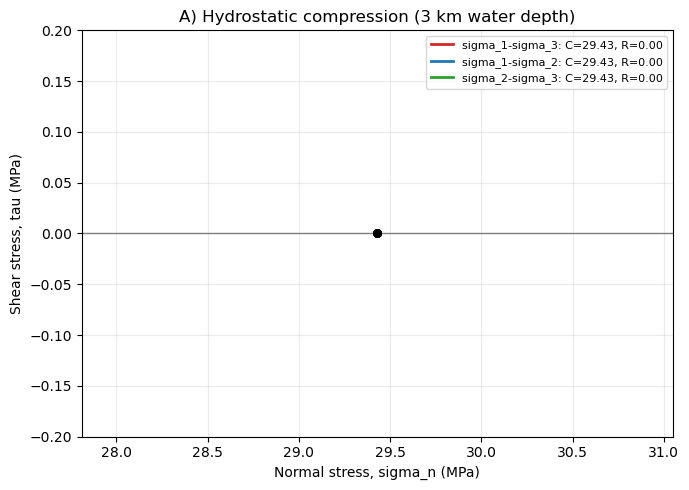

In [55]:
case_name = "A) Hydrostatic compression (3 km water depth)"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

### *Case B: Uniaxial tension*

Principal stresses:

$$\sigma_1 = 0\ \text{MPa}, \quad \sigma_2 = 0\ \text{MPa}, \quad \sigma_3 = -5\ \text{MPa}$$

Stress matrix:

$$[\sigma]_B =
\begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & -5
\end{bmatrix}\ \text{MPa}$$

Mohr representation: one non-zero circle between $\sigma_1$ and $\sigma_3$ (same as $\sigma_2$ and $\sigma_3$ because $\sigma_1 = \sigma_2$).

B) Uniaxial tension
sigma_1=0.00 MPa, sigma_2=0.00 MPa, sigma_3=-5.00 MPa
Stress matrix [MPa]:
[[ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -5.]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=-2.50, R=2.50
  (sigma_1, sigma_2): C=0.00, R=0.00
  (sigma_2, sigma_3): C=-2.50, R=2.50


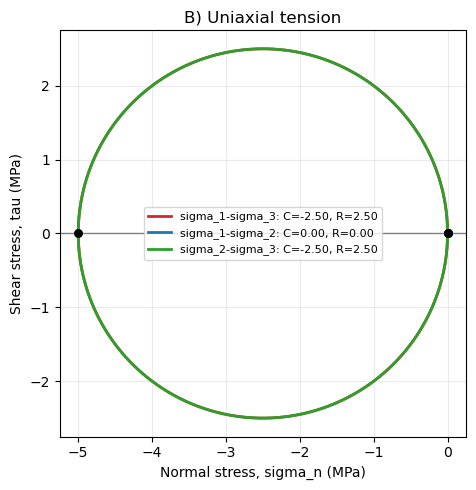

In [56]:
case_name = "B) Uniaxial tension"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

### *Case C: Triaxial compression*

Principal stresses:

$$\sigma_1 = 10\ \text{MPa}, \quad \sigma_2 = 8\ \text{MPa}, \quad \sigma_3 = 5\ \text{MPa}$$

Stress matrix:

$$[\sigma]_C =
\begin{bmatrix}
10 & 0 & 0 \\
0 & 8 & 0 \\
0 & 0 & 5
\end{bmatrix}\ \text{MPa}$$

Mohr representation: three distinct circles in the compressive stress domain.

C) Triaxial compression
sigma_1=10.00 MPa, sigma_2=8.00 MPa, sigma_3=5.00 MPa
Stress matrix [MPa]:
[[10.  0.  0.]
 [ 0.  8.  0.]
 [ 0.  0.  5.]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=7.50, R=2.50
  (sigma_1, sigma_2): C=9.00, R=1.00
  (sigma_2, sigma_3): C=6.50, R=1.50


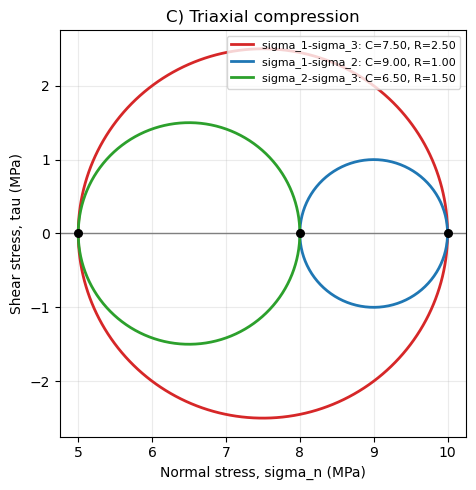

In [57]:
case_name = "C) Triaxial compression"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

### *Case D: Tension and compression*

Principal stresses:

$$\sigma_1 = 10\ \text{MPa}, \quad \sigma_2 = 0\ \text{MPa}, \quad \sigma_3 = -3\ \text{MPa}$$

Stress matrix:

$$[\sigma]_D =
\begin{bmatrix}
10 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & -3
\end{bmatrix}\ \text{MPa}$$

Mohr representation: mixed compression-tension state, with circles spanning negative and positive normal stress.

D) Tension and compression
sigma_1=10.00 MPa, sigma_2=0.00 MPa, sigma_3=-3.00 MPa
Stress matrix [MPa]:
[[10.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -3.]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=3.50, R=6.50
  (sigma_1, sigma_2): C=5.00, R=5.00
  (sigma_2, sigma_3): C=-1.50, R=1.50


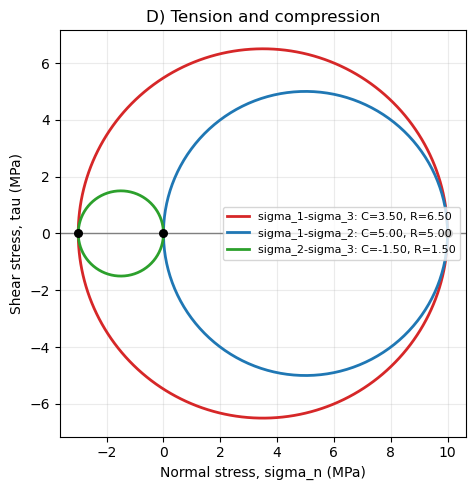

In [58]:
case_name = "D) Tension and compression"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

**Interpretation Summary**

- Case A (hydrostatic compression): all principal stresses are equal, so all three Mohr circles collapse to one point at $\sigma_n = 29.43$ MPa and $\tau = 0$.
- Case B (uniaxial tension): one stress is tensile ($\sigma_3 = -5$ MPa), producing circles that cross into negative normal stress domain.
- Case C (triaxial compression): all stresses are compressive, producing three distinct circles entirely in positive $\sigma_n$ range.
- Case D (tension + compression): mixed stress state gives the largest spread, from negative to positive normal stress, with the largest circle from $\sigma_1$ to $\sigma_3$.